# BÀI TẬP 2 - ANN: Nhận dạng chữ viết số MNIST
**Dataset:** MNIST (built-in TensorFlow)
**Labels:** Số 0 → 9

In [1]:
# ==============================================================
# BƯỚC 1: NẠP THƯ VIỆN
# ==============================================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# ==============================================================
# BƯỚC 2: ĐỌC TẬP DỮ LIỆU MNIST
# ==============================================================
class_names = [f'Số {i}' for i in range(10)]

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print('X_train shape:', X_train.shape)  # (60000, 28, 28)
print('y_train shape:', y_train.shape)
print('X_test shape: ', X_test.shape)   # (10000, 28, 28)
print('y_test shape: ', y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape:  (10000, 28, 28)
y_test shape:  (10000,)


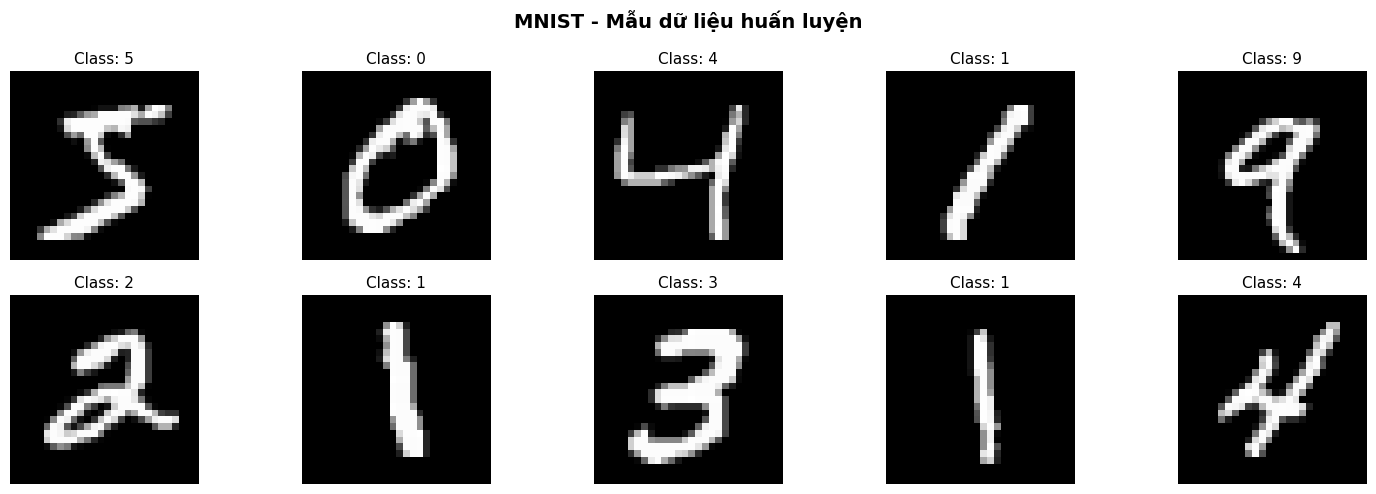

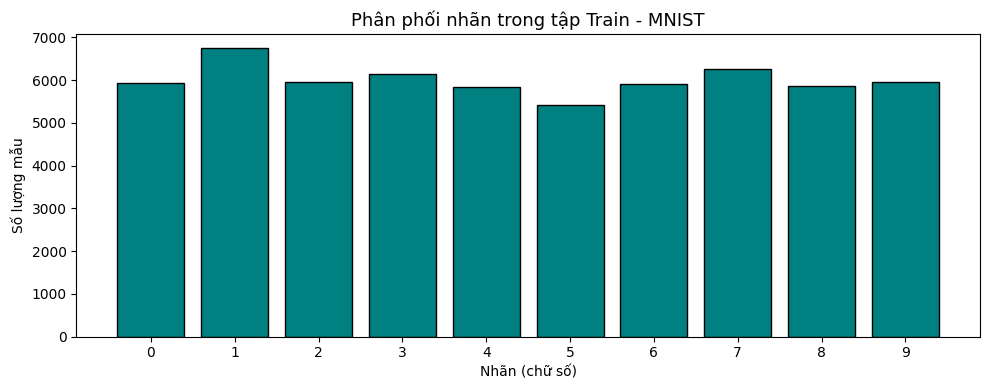

In [3]:
# ==============================================================
# BƯỚC 3: TRỰC QUAN HÓA DỮ LIỆU
# ==============================================================
fig, axes = plt.subplots(2, 5, figsize=(15, 5))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(X_train[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f'Class: {y_train[i]}', fontsize=11)
    axes[i].axis('off')
plt.suptitle('MNIST - Mẫu dữ liệu huấn luyện', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Biểu đồ phân phối nhãn
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10, 4))
plt.bar([str(i) for i in unique], counts, color='teal', edgecolor='black')
plt.title('Phân phối nhãn trong tập Train - MNIST', fontsize=13)
plt.xlabel('Nhãn (chữ số)')
plt.ylabel('Số lượng mẫu')
plt.tight_layout()
plt.show()

In [4]:
# ==============================================================
# BƯỚC 4: XỬ LÝ DỮ LIỆU
# ==============================================================
# Reshape từ (28,28) -> (784,)
X_train_flat = X_train.reshape(60000, 784).astype('float32')
X_test_flat  = X_test.reshape(10000, 784).astype('float32')

# Feature scaling về [0, 1]
minmax = MinMaxScaler()
X_train_flat = minmax.fit_transform(X_train_flat)
X_test_flat  = minmax.transform(X_test_flat)

print('Số classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

Số classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


In [5]:
# ==============================================================
# BƯỚC 5: XÂY DỰNG MÔ HÌNH ANN
# ==============================================================
model = Sequential()

# Hidden layer 1
model.add(Dense(input_dim=X_train_flat.shape[1], units=256,
                kernel_initializer='uniform', activation='relu'))
model.add(Dropout(0.2))

# Hidden layer 2
model.add(Dense(units=128, kernel_initializer='uniform', activation='relu'))
model.add(Dropout(0.2))

# Output layer
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ==============================================================
# BƯỚC 6: HUẤN LUYỆN MÔ HÌNH
# ==============================================================
model_fit = model.fit(X_train_flat, y_train,
                      validation_split=0.1,
                      epochs=20,
                      batch_size=128,
                      verbose=1)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8724 - loss: 0.4396 - val_accuracy: 0.9600 - val_loss: 0.1487
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9504 - loss: 0.1696 - val_accuracy: 0.9707 - val_loss: 0.1018
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9643 - loss: 0.1199 - val_accuracy: 0.9717 - val_loss: 0.0918
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9720 - loss: 0.0920 - val_accuracy: 0.9768 - val_loss: 0.0772
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9769 - loss: 0.0746 - val_accuracy: 0.9813 - val_loss: 0.0672
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9798 - loss: 0.0632 - val_accuracy: 0.9787 - val_loss: 0.0740
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9829 - loss: 0.0547 - val_accuracy: 0.9812 - val_loss: 0.0635
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9847 - loss: 0.0477 - val_accuracy:

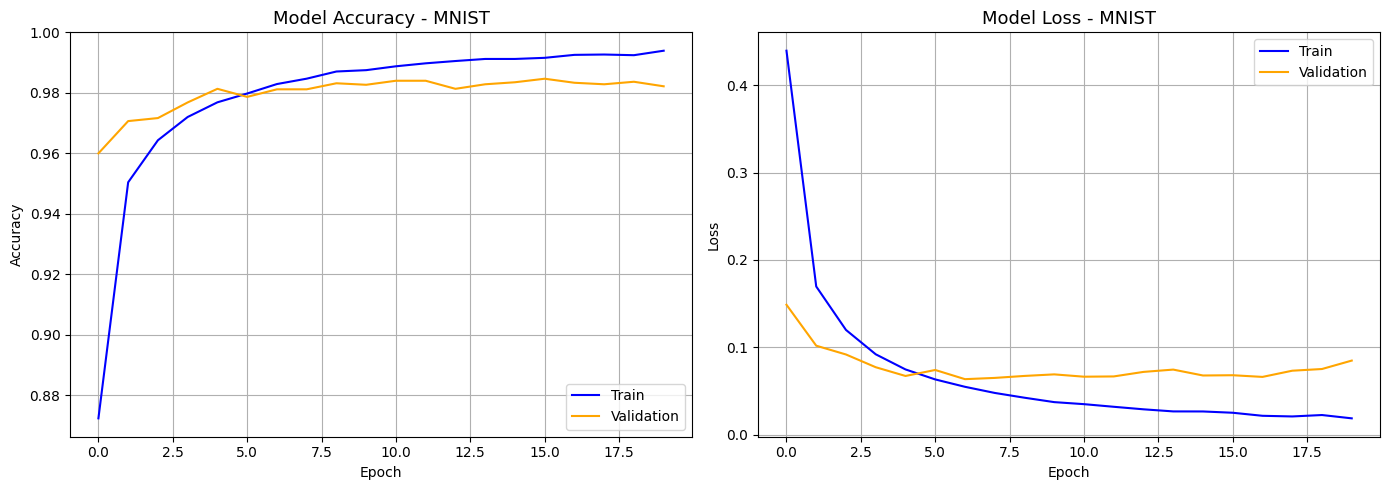

In [7]:
# ==============================================================
# BƯỚC 7: ĐÁNH GIÁ MÔ HÌNH - BIỂU ĐỒ ACCURACY & LOSS
# ==============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(model_fit.history['accuracy'], label='Train', color='blue')
axes[0].plot(model_fit.history['val_accuracy'], label='Validation', color='orange')
axes[0].set_title('Model Accuracy - MNIST', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')
axes[0].grid(True)

axes[1].plot(model_fit.history['loss'], label='Train', color='blue')
axes[1].plot(model_fit.history['val_loss'], label='Validation', color='orange')
axes[1].set_title('Model Loss - MNIST', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')
axes[1].grid(True)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

=== Classification Report ===
              precision    recall  f1-score   support

        Số 0       0.99      0.99      0.99       980
        Số 1       0.99      0.99      0.99      1135
        Số 2       0.98      0.99      0.98      1032
        Số 3       0.97      0.98      0.98      1010
        Số 4       0.99      0.98      0.98       982
        Số 5       0.99      0.97      0.98       892
        Số 6       0.98      0.99      0.99       958
        Số 7       0.98      0.98      0.98      1028
        Số 8       0.98      0.98      0.98       974
        Số 9       0.98      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



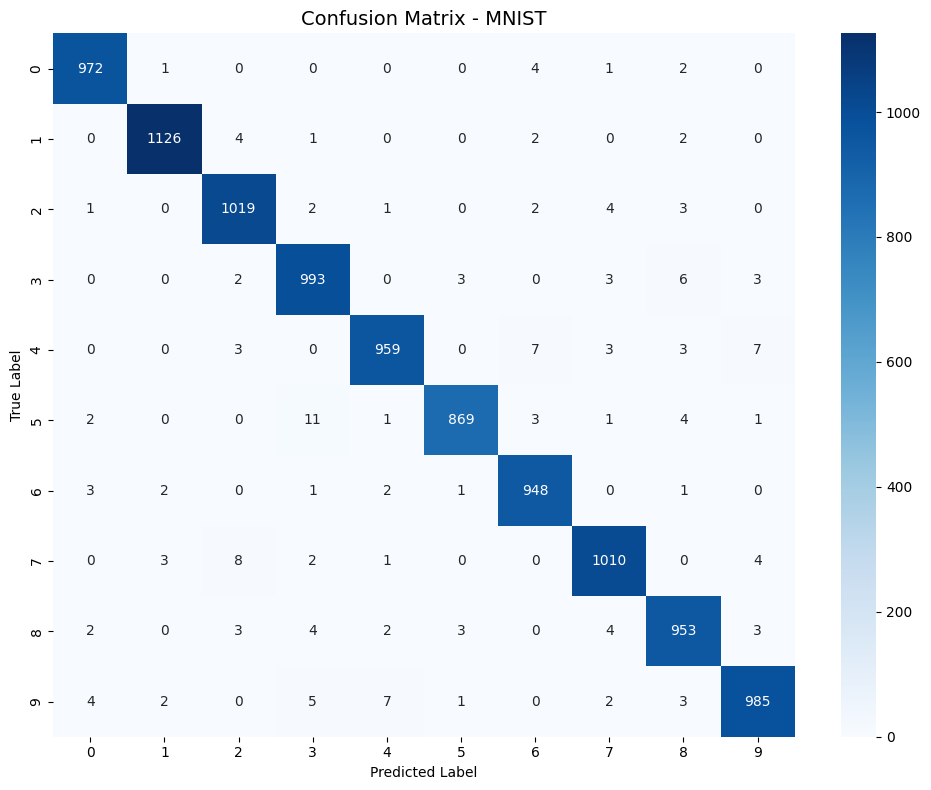


Test Accuracy: 0.9834 | Test Loss: 0.0692


In [8]:
# ==============================================================
# BƯỚC 8: CONFUSION MATRIX & CLASSIFICATION REPORT
# ==============================================================
y_pred = np.argmax(model.predict(X_test_flat), axis=1)

print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - MNIST', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

loss, acc = model.evaluate(X_test_flat, y_test, verbose=0)
print(f'\nTest Accuracy: {acc:.4f} | Test Loss: {loss:.4f}')

Dự báo mẫu 0: 7 | Thực tế: 7
Dự báo mẫu 10: 0 | Thực tế: 0


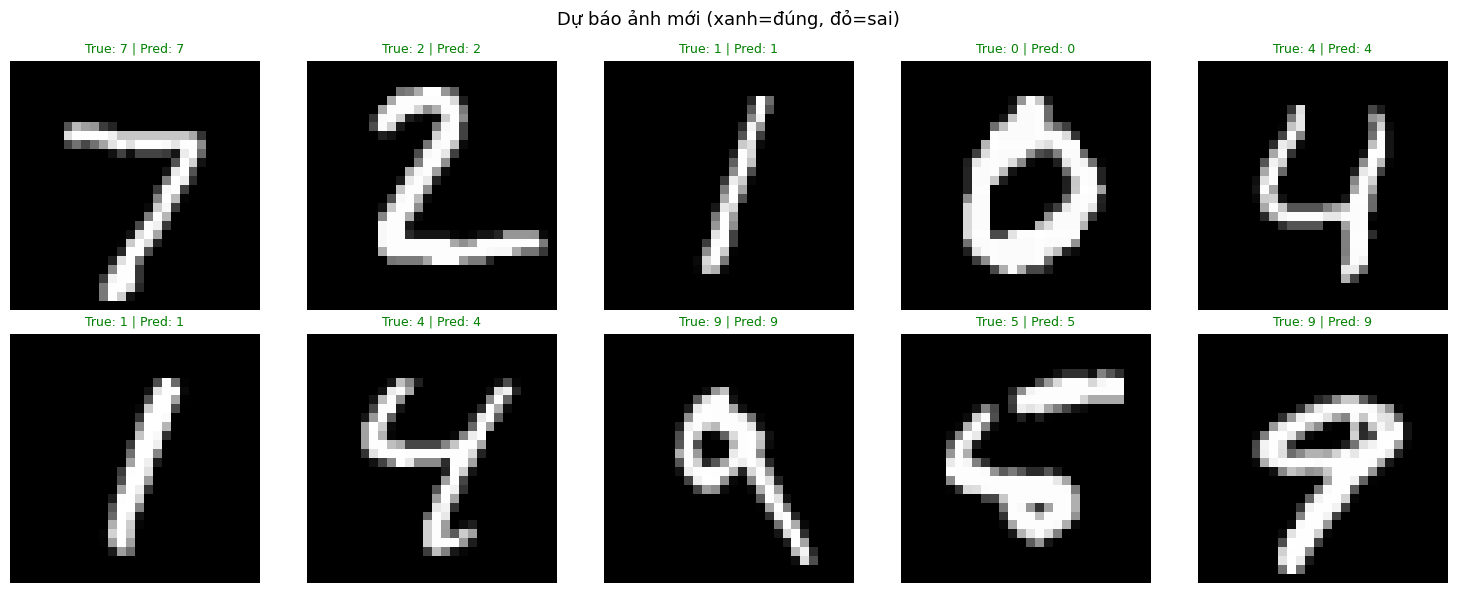

In [9]:
# ==============================================================
# BƯỚC 9: DỰ BÁO ẢNH MỚI
# ==============================================================
print('Dự báo mẫu 0:', np.argmax(model.predict(X_test_flat[0:1], verbose=0)), '| Thực tế:', y_test[0])
print('Dự báo mẫu 10:', np.argmax(model.predict(X_test_flat[10:11], verbose=0)), '| Thực tế:', y_test[10])

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()
for i in range(10):
    pred = np.argmax(model.predict(X_test_flat[i:i+1], verbose=0))
    true = y_test[i]
    color = 'green' if pred == true else 'red'
    axes[i].imshow(X_test[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f'True: {true} | Pred: {pred}', color=color, fontsize=9)
    axes[i].axis('off')
plt.suptitle('Dự báo ảnh mới (xanh=đúng, đỏ=sai)', fontsize=13)
plt.tight_layout()
plt.show()